# Soybean Cultivars Clustering

This notebook covers K-Means++ initialization, Silhouette evaluation, optimal cluster selection, Mahalanobis vs. Euclidean distance comparison, and a quality benchmark.

---
## Section 1: Overview and Improvements of K-Means++ Algorithm

### Standard K-Means Drawback
In standard K-Means clustering, the initial centroids are chosen uniformly at random from the dataset. This random initialization can easily lead to selecting initial centroids that are close to each other, resulting in poor local minima, slow convergence, and inconsistent cluster assignments.

### K-Means++ Improvement
The **K-Means++** algorithm addresses this sensitivity by introducing a smart probabilistic initialization scheme:
1. Choose the first centroid $c_1$ uniformly at random from the data points.
2. For each data point $x$, calculate $D(x)$, the shortest Euclidean distance to the nearest already chosen centroid.
3. Select the next centroid $c_i$ from the data points with a probability proportional to $D(x)^2$:
   $$P(x) = \frac{D(x)^2}{\sum_{x'} D(x')^2}$$
4. Repeat steps 2 and 3 until $k$ centroids are selected.

**Key Benefit:** By spreading out the initial centroids across the feature space, K-Means++ achieves a mathematically proven $O(\log k)$-competitive guarantee relative to the optimal solution, significantly reducing convergence time and improving final clustering quality.

---
## Section 2: Research and Explanation of the Silhouette Coefficient

The **Silhouette Coefficient** evaluates the quality of a clustering structure without relying on external class labels.

For a given sample $i$:
- **$a(i)$ (Intra-cluster dissimilarity):** The average Euclidean distance between sample $i$ and all other points in the same cluster $C_A$.
  $$a(i) = \frac{1}{|C_A| - 1} \sum_{j \in C_A, j \neq i} d(i, j)$$
- **$b(i)$ (Inter-cluster dissimilarity):** The average Euclidean distance between sample $i$ and all points in the nearest neighbor cluster $C_B \neq C_A$.
  $$b(i) = \min_{B \neq A} \frac{1}{|C_B|} \sum_{j \in C_B} d(i, j)$$

The Silhouette Coefficient $s(i)$ for sample $i$ is defined as:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

**Interpretation of $s(i)$:**
- $s(i) \approx +1$: Sample $i$ is well-clustered and far from neighboring clusters.
- $s(i) \approx 0$: Sample $i$ lies close to the decision boundary between two clusters.
- $s(i) \approx -1$: Sample $i$ has been assigned to the wrong cluster.

*Note:* The overall Silhouette Score is the mean of $s(i)$ over all samples. It requires at least $k = 2$ clusters to be calculated.

---
## Section 3: Optimal Cluster Selection using K-Means++ and Silhouette Score

In this section, we apply K-Means++ with Euclidean distance for $k \in [2, 10]$ and evaluate the Silhouette Coefficient to identify the optimal number of clusters.

Optimal number of clusters (k): 2


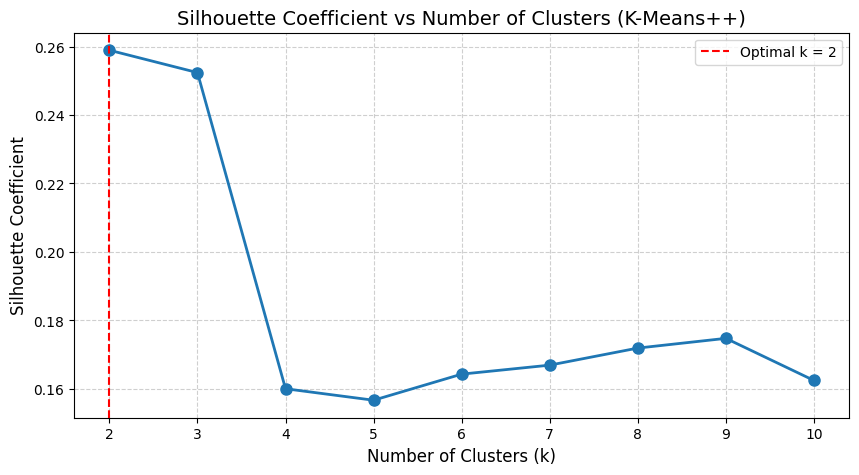

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv('datasets/dataset-Q6.csv')
X_raw = df.select_dtypes(include=[np.number]).values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Evaluate Silhouette score for k = 2 to 10 (k=1 is undefined for Silhouette Score)
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels, metric='euclidean')
    silhouette_scores.append(score)

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f'Optimal number of clusters (k): {optimal_k}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.title('Silhouette Coefficient vs Number of Clusters (K-Means++)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Coefficient', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

---
## Section 4: Mahalanobis Distance vs. Euclidean Distance Analysis

### Distance Formulations
- **Euclidean Distance:**
  $$d_E(x, y) = \sqrt{(x - y)^T (x - y)}$$
- **Mahalanobis Distance:**
  $$d_M(x, y) = \sqrt{(x - y)^T \Sigma^{-1} (x - y)}$$
  where $\Sigma$ is the sample covariance matrix of the data.

### Comparative Analysis
- **Advantage of Mahalanobis Distance over Euclidean Distance:**
  Mahalanobis distance accounts for variance along each feature axis and correlations between features. It is scale-invariant and effectively handles non-spherical (ellipsoidal) cluster geometries, whereas Euclidean distance assumes isotropic variances and zero correlation.

- **Disadvantage of Mahalanobis Distance over Euclidean Distance:**
  Mahalanobis distance requires estimating and inverting the $p \times p$ covariance matrix $\Sigma$, incurring $O(p^3)$ computational complexity. Furthermore, if feature multicollinearity exists or sample size $N < p$, the covariance matrix becomes singular or ill-conditioned, requiring matrix regularization.

---
## Section 5: Comparative Evaluation of Euclidean vs. Mahalanobis K-Means++ Clustering

Using the optimal cluster count $k^*$ identified in Section 3 and a fixed deterministic initialization, we compare clustering quality between Euclidean K-Means++ and Mahalanobis K-Means++.

In [2]:
from scipy.spatial.distance import pdist, squareform

class MahalanobisKMeans:
    def __init__(self, n_clusters, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit_predict(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        cov = np.cov(X, rowvar=False) + 1e-5 * np.eye(n_features)
        inv_cov = np.linalg.inv(cov)
        self.inv_cov_ = inv_cov

        centroids = np.zeros((self.n_clusters, n_features))
        centroids[0] = X[np.random.choice(n_samples)]

        for c_idx in range(1, self.n_clusters):
            dists = np.zeros((n_samples, c_idx))
            for i in range(c_idx):
                diff = X - centroids[i]
                dists[:, i] = np.sum(np.dot(diff, inv_cov) * diff, axis=1)
            min_dists = np.min(dists, axis=1)
            probs = min_dists / np.sum(min_dists)
            cumprobs = np.cumsum(probs)
            r = np.random.rand()
            chosen_idx = np.searchsorted(cumprobs, r)
            centroids[c_idx] = X[chosen_idx]

        for _ in range(self.max_iter):
            dists = np.zeros((n_samples, self.n_clusters))
            for i in range(self.n_clusters):
                diff = X - centroids[i]
                dists[:, i] = np.sqrt(np.sum(np.dot(diff, inv_cov) * diff, axis=1))
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(centroids)
            for i in range(self.n_clusters):
                if np.sum(labels == i) > 0:
                    new_centroids[i] = X[labels == i].mean(axis=0)
                else:
                    new_centroids[i] = centroids[i]

            if np.allclose(centroids, new_centroids):
                break
            centroids = new_centroids

        self.centroids_ = centroids
        return labels

# 1. Euclidean K-Means++
kmeans_euc = KMeans(n_clusters=optimal_k, init='k-means++', random_state=RANDOM_SEED, n_init=10)
labels_euc = kmeans_euc.fit_predict(X)
score_euc = silhouette_score(X, labels_euc, metric='euclidean')

# 2. Mahalanobis K-Means++
kmeans_mah = MahalanobisKMeans(n_clusters=optimal_k, random_state=RANDOM_SEED)
labels_mah = kmeans_mah.fit_predict(X)

# Compute Pairwise Mahalanobis Distance for Silhouette score
cov = np.cov(X, rowvar=False) + 1e-5 * np.eye(X.shape[1])
inv_cov = np.linalg.inv(cov)
dist_mah_matrix = squareform(pdist(X, metric='mahalanobis', VI=inv_cov))
score_mah = silhouette_score(dist_mah_matrix, labels_mah, metric='precomputed')

# Display Comparison Table
comparison_df = pd.DataFrame({
    'Clustering Metric / Distance': ['Euclidean Distance K-Means++', 'Mahalanobis Distance K-Means++'],
    'Optimal k': [optimal_k, optimal_k],
    'Silhouette Score': [score_euc, score_mah]
})
print('\n=== Clustering Quality Benchmark ===')
print(comparison_df.to_string(index=False))


=== Clustering Quality Benchmark ===
  Clustering Metric / Distance  Optimal k  Silhouette Score
  Euclidean Distance K-Means++          2          0.258929
Mahalanobis Distance K-Means++          2          0.089929
